### Задание

Создайте нейронную сеть, распознающую рукописные цифры. Используя подготовленную базу и шаблон ноутбука, нормируйте данные, создайте и обучите сверточную сеть.

**Параметры модели:** сеть должна содержать минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображать.

**В конце** выведите график обучения: доли верных ответов на обучающей и проверочной выборках.


## 1. Загрузка датасета MNIST

In [1]:
# загрузка датасета MNIST

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2. Импорт необходимых библиотек

In [2]:
# Подключение утилит для to_categorical
from tensorflow.keras import utils

# Подключение библиотеки для работы с массивами
import numpy as np

# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt

# Подключение библиотеки для генерации случайных чисел
import random

# Подключение класса для работы с изображением
from PIL import Image

# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

## 3. Визуализация примеров цифр из датасета

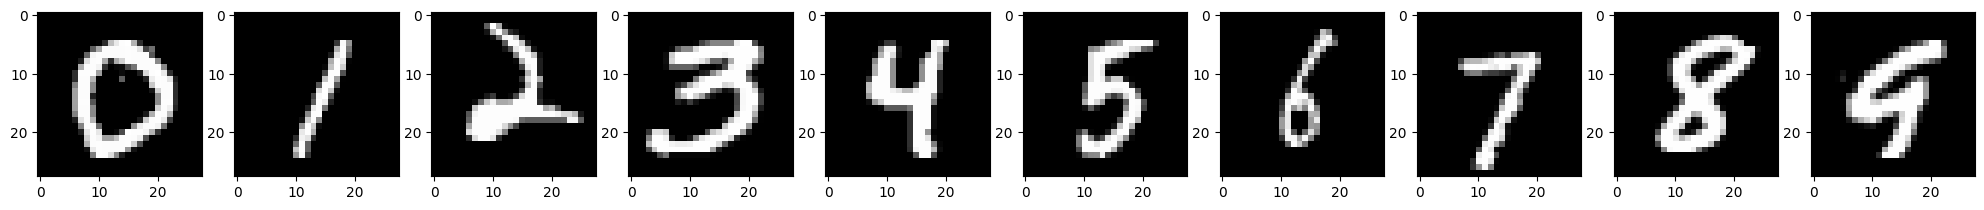

In [3]:
# вывод изображений каждого класса для ознакомления с датасетом

fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
  label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
  index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
  img = x_train[index] # выбираем из x_train нужное положение
  axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

## 4. Подготовка данных

In [4]:
# добавляем размерность массиву mnist, чтобы сеть поняла что это чб
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

# преобразуем выборки с ответами в OHE
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

# посмотрим форматы выборок перед обучением
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print()
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)

y_train: (60000, 10)
y_test: (10000, 10)


## 5. Нормализация данных 

In [ ]:
# нормализация данных (приведение к диапазону 0–1)

x_train = x_train / 255.0
x_test = x_test / 255.0

## 6. Создание проверочной выборки из обучающей

In [10]:
from sklearn.model_selection import train_test_split

# выделяем 10000 образцов под проверку
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=10000,
    random_state=42
)

print(f"Обучающая: {x_train.shape}, Проверочная: {x_val.shape}, Тестовая: {x_test.shape}")

Обучающая: (50000, 28, 28, 1), Проверочная: (10000, 28, 28, 1), Тестовая: (10000, 28, 28, 1)


## 7. Создание архитектуры сверточной нейронной сети

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense

model = Sequential()

# сверточный слой 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# сверточный слой 2
model.add(Conv2D(64, (3, 3), activation='relu'))

# слой подвыборки (1 шт)
model.add(MaxPooling2D(pool_size=(2, 2)))

# слой нормализации (1 шт)
model.add(BatchNormalization())

# переход к полносвязным слоям
model.add(Flatten())

# полносвязный слой
model.add(Dense(128, activation='relu'))

# слой регуляризации (1 шт)
model.add(Dropout(0.5))

# выходной слой
model.add(Dense(10, activation='softmax'))

## 8. Компиляция модели

In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,138 (4.58 MB)

 Trainable params: 1,200,010 (4.58 MB)

 Non-trainable params: 128 (512.00 B)

## 9. Обучение модели

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9365 - loss: 0.2121 - val_accuracy: 0.9821 - val_loss: 0.2982
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9772 - loss: 0.0768 - val_accuracy: 0.9874 - val_loss: 0.0440
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9836 - loss: 0.0543 - val_accuracy: 0.9866 - val_loss: 0.0463
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9868 - loss: 0.0418 - val_accuracy: 0.9895 - val_loss: 0.0426
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9901 - val_loss: 0.0366
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9916 - loss: 0.0270 - val_accuracy: 0.9893 - val_loss: 0.0398
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9918 - loss: 0.0250 - val_accuracy: 0.9877 - val_loss: 0.0526
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9917 - loss: 0.0261 - val_accuracy: 

## 10. График обучения: доля верных ответов

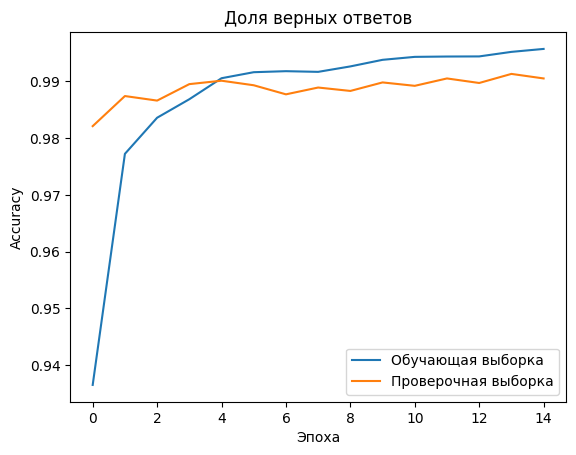

In [20]:
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')

plt.title('Доля верных ответов')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## 11. Оценка модели на тестовой выборке

In [24]:
# оценка модели на тестовых данных
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Ошибка на тестовой выборке: {test_loss:.4f}")

Точность на тестовой выборке: 0.9906 (99.06%)
Ошибка на тестовой выборке: 0.0458


## 12. Сохранение обученной модели

In [22]:
# сохранение обученной модели
model.save("cnn_mnist_model.keras")